In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/digit-recognizer/sample_submission.csv
/kaggle/input/competitions/digit-recognizer/train.csv
/kaggle/input/competitions/digit-recognizer/test.csv


In [2]:
#Load Data
df = pd.read_csv('/kaggle/input/competitions/digit-recognizer/train.csv')
df.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


# KNN WITHOUT PCA

In [4]:
X = df.iloc[:,1:]
y = df.iloc[:,0]

In [5]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [6]:
from sklearn.neighbors import KNeighborsClassifier

In [9]:
knn = KNeighborsClassifier()

In [10]:
knn.fit(X_train,y_train)

KNeighborsClassifier()

In [12]:
y_pred = knn.predict(X_test)
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)
#Without PCA 96% Accuracy with 784 features + Take more time

0.9648809523809524

# KNN WITH PCA

In [16]:
#Load Data
df = pd.read_csv('/kaggle/input/competitions/digit-recognizer/train.csv')

In [17]:
#Step_1-Scaling using Standardisation
'''Why scaling is important before PCA?
PCA is variance-based.
Large-scale features dominate variance.'''
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [19]:
X_train = scaler.fit_transform(X_train) #Fit + Transform testing data
X_test = scaler.transform(X_test) #Only Transfor training data

In [22]:
#Step_2-PCA
from sklearn.decomposition import PCA
pca = PCA(n_components=100) #Out of 784 features we have taking only 100 features whose eigenvector/eigenvalue is largest means those who explain max variance

In [24]:
X_train_trf = pca.fit_transform(X_train)
X_test_trf = pca.transform(X_test)  #Never fit test data

In [29]:
print(pca.explained_variance_) #Eigenvalues of 100 PC
print(pca.components_) #Eigenvectors=PC directions
print(pca.explained_variance_ratio_) #PC explain 5.78% variance of feature space is retained

[40.67111198 29.17023401 26.74459621 20.85344792 18.14891878 15.8529825
 13.87108101 12.48058967 11.02794236 10.09582533  9.63317821  8.62785945
  8.06303131  7.89511749  7.44167929  7.17032873  6.73266373  6.62744023
  6.41499161  6.25808269  5.90495742  5.76521585  5.52084601  5.32003847
  5.18309925  4.93439597  4.90652171  4.71800493  4.49824444  4.43140305
  4.32604521  4.23491831  4.10335015  4.0673118   4.02362178  3.84130473
  3.81886146  3.71316498  3.60918108  3.47303214  3.42842989  3.38841159
  3.29157511  3.22927379  3.21745142  3.15810372  3.12620905  3.10412385
  3.05892795  3.03728188  2.96540461  2.94033669  2.86828564  2.82617865
  2.80038441  2.77411221  2.71978838  2.69394232  2.64724369  2.63065837
  2.56498699  2.53651735  2.48789582  2.44610051  2.42066567  2.37577156
  2.35505085  2.33408709  2.29804042  2.25323781  2.24106526  2.18913049
  2.17678604  2.15005558  2.13513807  2.11873568  2.09860149  2.08173945
  2.04964573  2.03090509  2.02167211  2.01348141  1.

In [25]:
knn = KNeighborsClassifier()
knn.fit(X_train_trf,y_train)

KNeighborsClassifier()

In [26]:
y_pred = knn.predict(X_test_trf)
accuracy_score(y_test,y_pred)
#After using PCA 95% Accuracy with only topmost 100 features ,less time

0.9544047619047619

# Important Points To Remember

In [31]:
#1.How many Components to select
'''Choose enough components to explain:
90% variance
Usually gives good performance.'''
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import numpy as np

# PCA with 90% variance retention
pca = PCA(n_components=0.90)

# Transform data
X_train_trf = pca.fit_transform(X_train)
X_test_trf = pca.transform(X_test)

# Check how many PCs selected
print("Number of Components Selected:", pca.n_components_)

# Total variance retained
print("Variance Retained:",
      np.sum(pca.explained_variance_ratio_))

# Train model
knn = KNeighborsClassifier()

knn.fit(X_train_trf, y_train)

# Prediction
y_pred = knn.predict(X_test_trf)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

Number of Components Selected: 223
Variance Retained: 0.9001324775058173
Accuracy: 0.9494047619047619


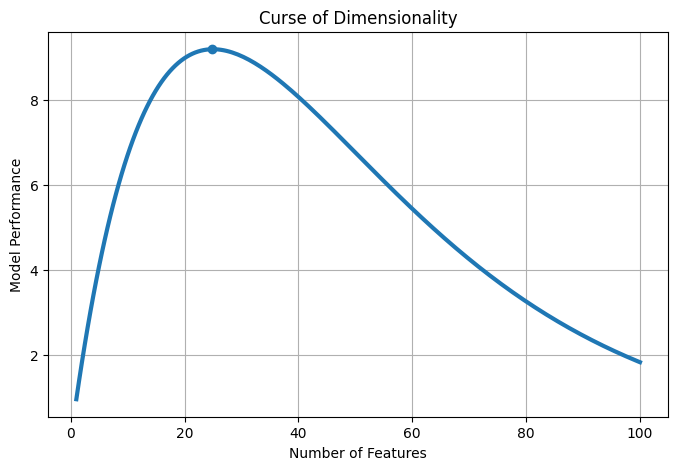

In [27]:
#***2.Curse Of Dimensionality***
import numpy as np
import matplotlib.pyplot as plt

# Number of features (dimensions)
features = np.linspace(1, 100, 200)

# Simulated model performance curve
# Initially increases, then decreases
performance = features * np.exp(-features / 25)

# Plot
plt.figure(figsize=(8,5))
plt.plot(features, performance, linewidth=3)

# Labels and title
plt.xlabel("Number of Features")
plt.ylabel("Model Performance")
plt.title("Curse of Dimensionality")

# Mark optimal point
optimal_idx = np.argmax(performance)
plt.scatter(features[optimal_idx], performance[optimal_idx])

plt.grid(True)
plt.show()

In [ ]:
#3.When PCA doesn't work well
'''Case 1: Equal Variance in All Directions
Case 2: Heavy Overlapping Data
Case 3: Non-Linear Patterns'''